To run this notebook, you have first to clone the repository held in https://github.com/pedropro/TACO for the TACO dataset, and place this in the root repository of the newly created repository.

In [1]:
import json
from pathlib import Path

original_data_path = Path("./data")
with open(Path.joinpath(original_data_path,"annotations.json"), "r") as f:
    taco_data = json.loads(f.read())
print(taco_data.keys())
annotations = taco_data["annotations"]
images = taco_data["images"]
number_annotations = len(annotations)
number_images = len(images)
print(f"Annotations: {number_annotations}")
print(f"Images: {number_images}")

dict_keys(['info', 'images', 'annotations', 'scene_annotations', 'licenses', 'categories', 'scene_categories'])
Annotations: 4784
Images: 1500


In [2]:
print(taco_data["categories"][0].keys())
bottle_ids = dict()
for category in taco_data["categories"]:
    if category["supercategory"].lower() == "bottle":
        bottle_ids[category["id"]] = category["name"]
print(bottle_ids)

dict_keys(['supercategory', 'id', 'name'])
{4: 'Other plastic bottle', 5: 'Clear plastic bottle', 6: 'Glass bottle'}


In [3]:
with open("bottle_ids.json", "w") as json_file:
    json.dump(bottle_ids, json_file, indent=4)

In [4]:
bottle_ids_path = Path("./bottle_ids.json")
output_path = Path("./yolo_bottle_dataset")
Path.joinpath(output_path,"images/train").mkdir(parents=True,exist_ok=True)
Path.joinpath(output_path,"images/val").mkdir(parents=True,exist_ok=True)
Path.joinpath(output_path,"labels/train").mkdir(parents=True,exist_ok=True)
Path.joinpath(output_path,"labels/val").mkdir(parents=True,exist_ok=True)

In [5]:
with open(bottle_ids_path, "r") as f:
    target_categories = list(map(int, list(json.load(f).keys())))
target_categories

[4, 5, 6]

In [6]:
annotations[0]

{'id': 1,
 'image_id': 0,
 'category_id': 6,
 'segmentation': [[561.0,
   1238.0,
   568.0,
   1201.0,
   567.0,
   1175.0,
   549.0,
   1127.0,
   538.0,
   1089.0,
   519.0,
   1043.0,
   517.0,
   1005.0,
   523.0,
   964.0,
   529.0,
   945.0,
   520.0,
   896.0,
   525.0,
   862.0,
   536.0,
   821.0,
   554.0,
   769.0,
   577.0,
   727.0,
   595.0,
   678.0,
   596.0,
   585.0,
   588.0,
   346.0,
   581.0,
   328.0,
   569.0,
   306.0,
   570.0,
   276.0,
   576.0,
   224.0,
   560.0,
   205.0,
   564.0,
   170.0,
   578.0,
   154.0,
   608.0,
   136.0,
   649.0,
   127.0,
   688.0,
   127.0,
   726.0,
   129.0,
   759.0,
   141.0,
   784.0,
   153.0,
   792.0,
   177.0,
   788.0,
   193.0,
   782.0,
   209.0,
   792.0,
   238.0,
   802.0,
   271.0,
   802.0,
   294.0,
   791.0,
   319.0,
   789.0,
   360.0,
   794.0,
   395.0,
   810.0,
   529.0,
   819.0,
   609.0,
   841.0,
   675.0,
   882.0,
   728.0,
   916.0,
   781.0,
   928.0,
   802.0,
   938.0,
   834.0,
   940.0,
  

In [7]:
display(images[0])

# Check if image id matches the position of the image in the list
for i in range(0,1500):
    if images[i]["id"] != i:
        print(False)

{'id': 0,
 'width': 1537,
 'height': 2049,
 'file_name': 'batch_1/000006.jpg',
 'license': None,
 'flickr_url': 'https://farm66.staticflickr.com/65535/33978196618_e30a59e0a8_o.png',
 'coco_url': None,
 'date_captured': None,
 'flickr_640_url': 'https://farm66.staticflickr.com/65535/33978196618_632623b4fc_z.jpg'}

In [8]:
image_id = annotations[846]["image_id"]
images[image_id]

{'id': 275,
 'width': 4032,
 'height': 3024,
 'file_name': 'batch_11/000074.jpg',
 'license': 'ODBL (c) OpenLitterMap & Contributors',
 'flickr_url': 'https://olm-s3.s3.eu-west-1.amazonaws.com/2019/04/18/LVJS2zKVBN3hM4RKnAJfvtyEpi9Raal6YNTiZPbc.jpeg',
 'flickr_640_url': None,
 'coco_url': None,
 'date_captured': None}

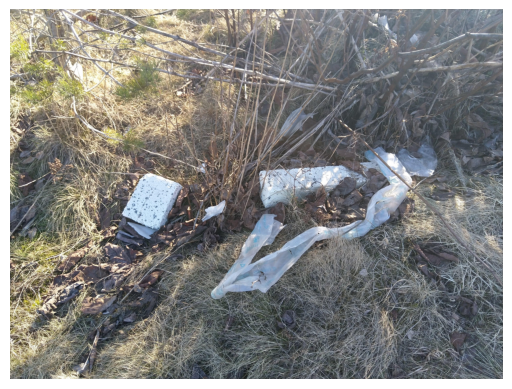

In [9]:
#Check if images match
import cv2
import matplotlib.pyplot as plt
file_name = images[image_id]["file_name"]
file_path = Path.joinpath(original_data_path,file_name)
img = cv2.imread(file_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [10]:
# Conversion from COCO to YOLO format code. Includes train/test split
!python adjust_dataset_format.py

Done!


Upload the "yolo_bottle_dataset" to your google drive for later training in colab.

# Checks

In [11]:
from pathlib import Path
train_images = list(Path("yolo_bottle_dataset/images/train").glob("*"))
train_labels = list(Path("yolo_bottle_dataset/labels/train").glob("*.txt"))
print(len(train_images), "images —", len(train_labels), "label files")
test_images = list(Path("yolo_bottle_dataset/images/val").glob("*"))
test_labels = list(Path("yolo_bottle_dataset/labels/val").glob("*.txt"))
print(len(test_images), "images —", len(test_labels), "label files")

248 images — 248 label files
74 images — 74 label files


In [12]:
missing = [p for p in train_images if (Path("yolo_bottle_dataset/labels/train")/(p.name.rsplit(".",1)[0]+".txt")).exists() is False]
print("Train images without label:", len(missing))
missing = [p for p in test_images if (Path("yolo_bottle_dataset/labels/val")/(p.name.rsplit(".",1)[0]+".txt")).exists() is False]
print("Test images without label:", len(missing))

Train images without label: 0
Test images without label: 0


In [13]:
import math
errors = []
for f in Path("yolo_bottle_dataset/labels/train").glob("*.txt"):
    for i,line in enumerate(f.read_text().strip().splitlines(),1):
        parts=line.split()
        if len(parts)!=5: errors.append((f,i,"len!=5")); continue
        cls,*vals=parts
        try:
            int(cls)
            vals=[float(v) for v in vals]
        except:
            errors.append((f,i,"parse"))
            continue
        if not all(0.0<=v<=1.0 for v in vals): errors.append((f,i,"out_of_range"))
        if vals[2]<=0 or vals[3]<=0: errors.append((f,i,"nonpos_w_h"))
print("Errors:", errors[:10])

for f in Path("yolo_bottle_dataset/labels/val").glob("*.txt"):
    for i,line in enumerate(f.read_text().strip().splitlines(),1):
        parts=line.split()
        if len(parts)!=5: errors.append((f,i,"len!=5")); continue
        cls,*vals=parts
        try:
            int(cls)
            vals=[float(v) for v in vals]
        except:
            errors.append((f,i,"parse"))
            continue
        if not all(0.0<=v<=1.0 for v in vals): errors.append((f,i,"out_of_range"))
        if vals[2]<=0 or vals[3]<=0: errors.append((f,i,"nonpos_w_h"))
print("Errors:", errors[:10])

Errors: []
Errors: []


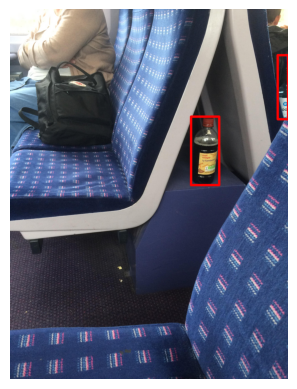

In [14]:
import cv2, matplotlib.pyplot as plt
img_p = Path("yolo_bottle_dataset/images/train") / "batch_3_IMG_5053.JPG"
lbl_p = Path("yolo_bottle_dataset/labels/train") / (img_p.stem + ".txt")
img = cv2.imread(str(img_p)); H,W = img.shape[:2]
for line in lbl_p.read_text().strip().splitlines():
    cls,x,y,w,h = map(float,line.split())
    x1=int((x-w/2)*W)
    y1=int((y-h/2)*H)
    x2=int((x+w/2)*W)
    y2=int((y+h/2)*H)
    cv2.rectangle(img,(x1,y1),(x2,y2),(0,0,255),20)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()